## Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic

Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

1. Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [3]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

2. Nạp dữ liệu, phân tích và loại bỏ features không cần thiết

In [4]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
features_response = df.columns.tolist()
print(features_response)

# Các cột cần loại bỏ
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


3. Xử lý dữ liệu (biến đổi và làm sạch)

In [6]:
df.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [7]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [8]:
#diền trung vị cho Age 
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# mã hóa giới tính 
df['Sex']= df['Sex'].map({'male': 0, 'female': 1})
# mã hóa Embarked
df['Embarked'] = df['Embarked'].map({'S':2, 'C':0, 'Q':1})

df.head()
df.isna().sum()
df.isnull().sum()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4700\706223971.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4700\706223971.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

4️. Tách dữ liệu train/test

In [9]:
from sklearn.model_selection import train_test_split
from sklearn import tree

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


5. Xây dựng cây quyết định

In [10]:
decision_tree = tree.DecisionTreeClassifier(max_depth=2, random_state=42)
decision_tree.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=2, random_state=42)

6. Vẽ cây 

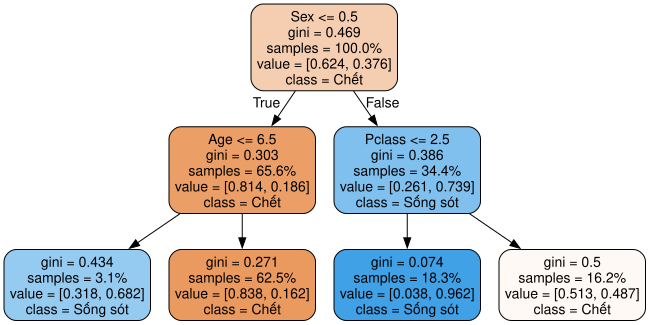

In [11]:
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz\bin'
dot_data = tree.export_graphviz(
    decision_tree,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=X_train.columns,
    proportion=True,
    class_names=['Chết', 'Sống sót']
)

graph = graphviz.Source(dot_data)
graph


7. Dánh giá mô hình 

In [12]:
from sklearn.metrics import accuracy_score

y_predict = decision_tree.predict(X_test)
print("Độ chính xác trên tập test:", accuracy_score(y_test, y_predict))


Độ chính xác trên tập test: 0.7653631284916201


Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV

1. Import thư viện

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree

2. Chuẩn bị dữ liệu 

In [14]:
df = pd.read_csv('train.csv')

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

items_to_remove = ['PassengerId', 'Name', 'Ticket', 'Cabin']
features_response = [c for c in df.columns if c not in items_to_remove]

# Tạo tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    df[features_response[1:]].values,
    df['Survived'].values,
    test_size=0.2,
    random_state=24
)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4700\4011641142.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4700\4011641142.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,2


3. Tìm tham số tối ưu cho model 

In [16]:
params = {'max_depth':[1,2,3,4,5,6,7,8,9,10],}
decision_tree_2 = tree.DecisionTreeClassifier(random_state=24)

cv = GridSearchCV(
    decision_tree_2,
    param_grid=params,
    scoring='roc_auc',
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True

    )
cv.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=24),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             return_train_score=True, scoring='roc_auc', verbose=1)

4. Vẽ biểu đồ đánh giá mô hình với các độ sâu khác nhau

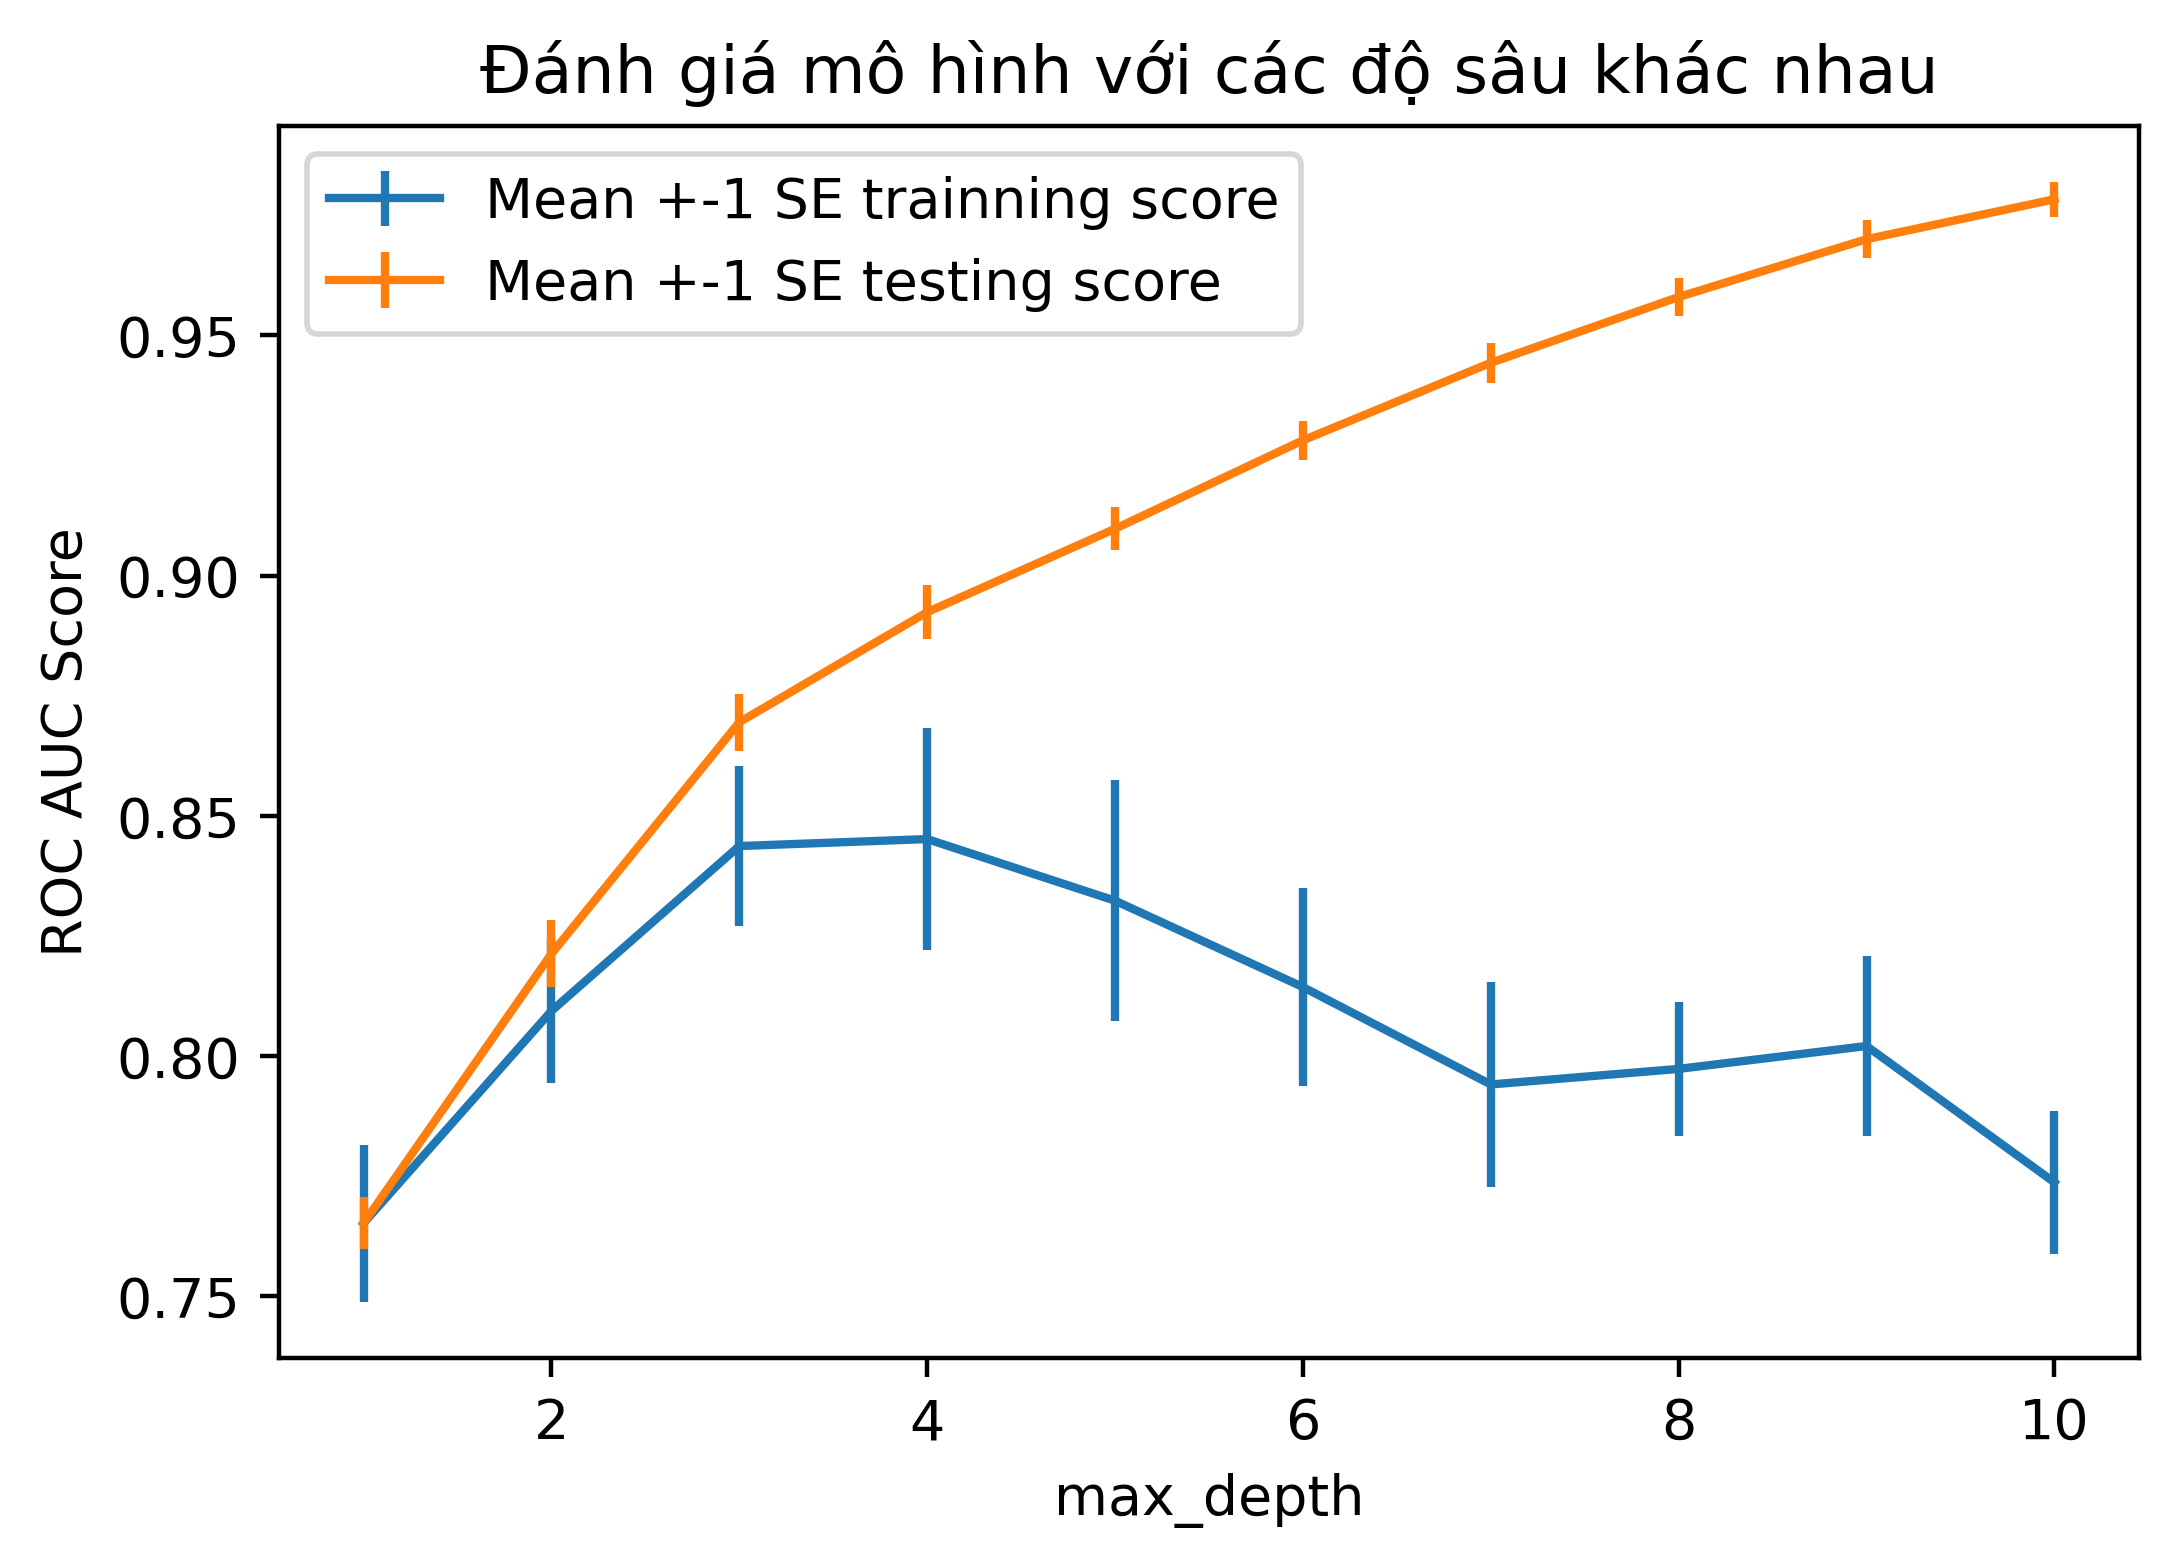

In [17]:
cv_results_df = pd.DataFrame(cv.cv_results_)
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    cv_results_df['param_max_depth'],
    cv_results_df['mean_test_score'],
    yerr=cv_results_df['std_test_score']/np.sqrt(4),
    label = 'Mean +-1 SE trainning score'
)
ax.errorbar(
    cv_results_df['param_max_depth'],
    cv_results_df['mean_train_score'],
    yerr=cv_results_df['std_train_score']/np.sqrt(4),
    label = 'Mean +-1 SE testing score'
)
ax.legend()
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC AUC Score')
plt.title("Đánh giá mô hình với các độ sâu khác nhau")
plt.show()

Nhiệm vụ 3: Xây dựng randomforest 

1. Import thư viện 

In [ ]:
from sklearn.ensemble import RandomForestClassifier


2. Tạo mô hình rừng cây & GridSearch

In [22]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.ensemble import RandomForestClassifier
#random forest với các tham số 
rf = RandomForestClassifier(
    n_estimators=10,
    criterion='gini',
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=4
)
# Dải tham số cần tìm (số lượng cây trong rừng)
rf_params_ex = {'n_estimators': list(range(10, 110, 10))}

# công cụ tìm kiếm với random forest với các tham số tốt nhất 
cv_rf_ex = GridSearchCV(
    rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=4, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

Rất có thể GridSearchCV đã tìm ra giá trị tốt nhất cho n_estimators chính là 100 khi max_depth=4

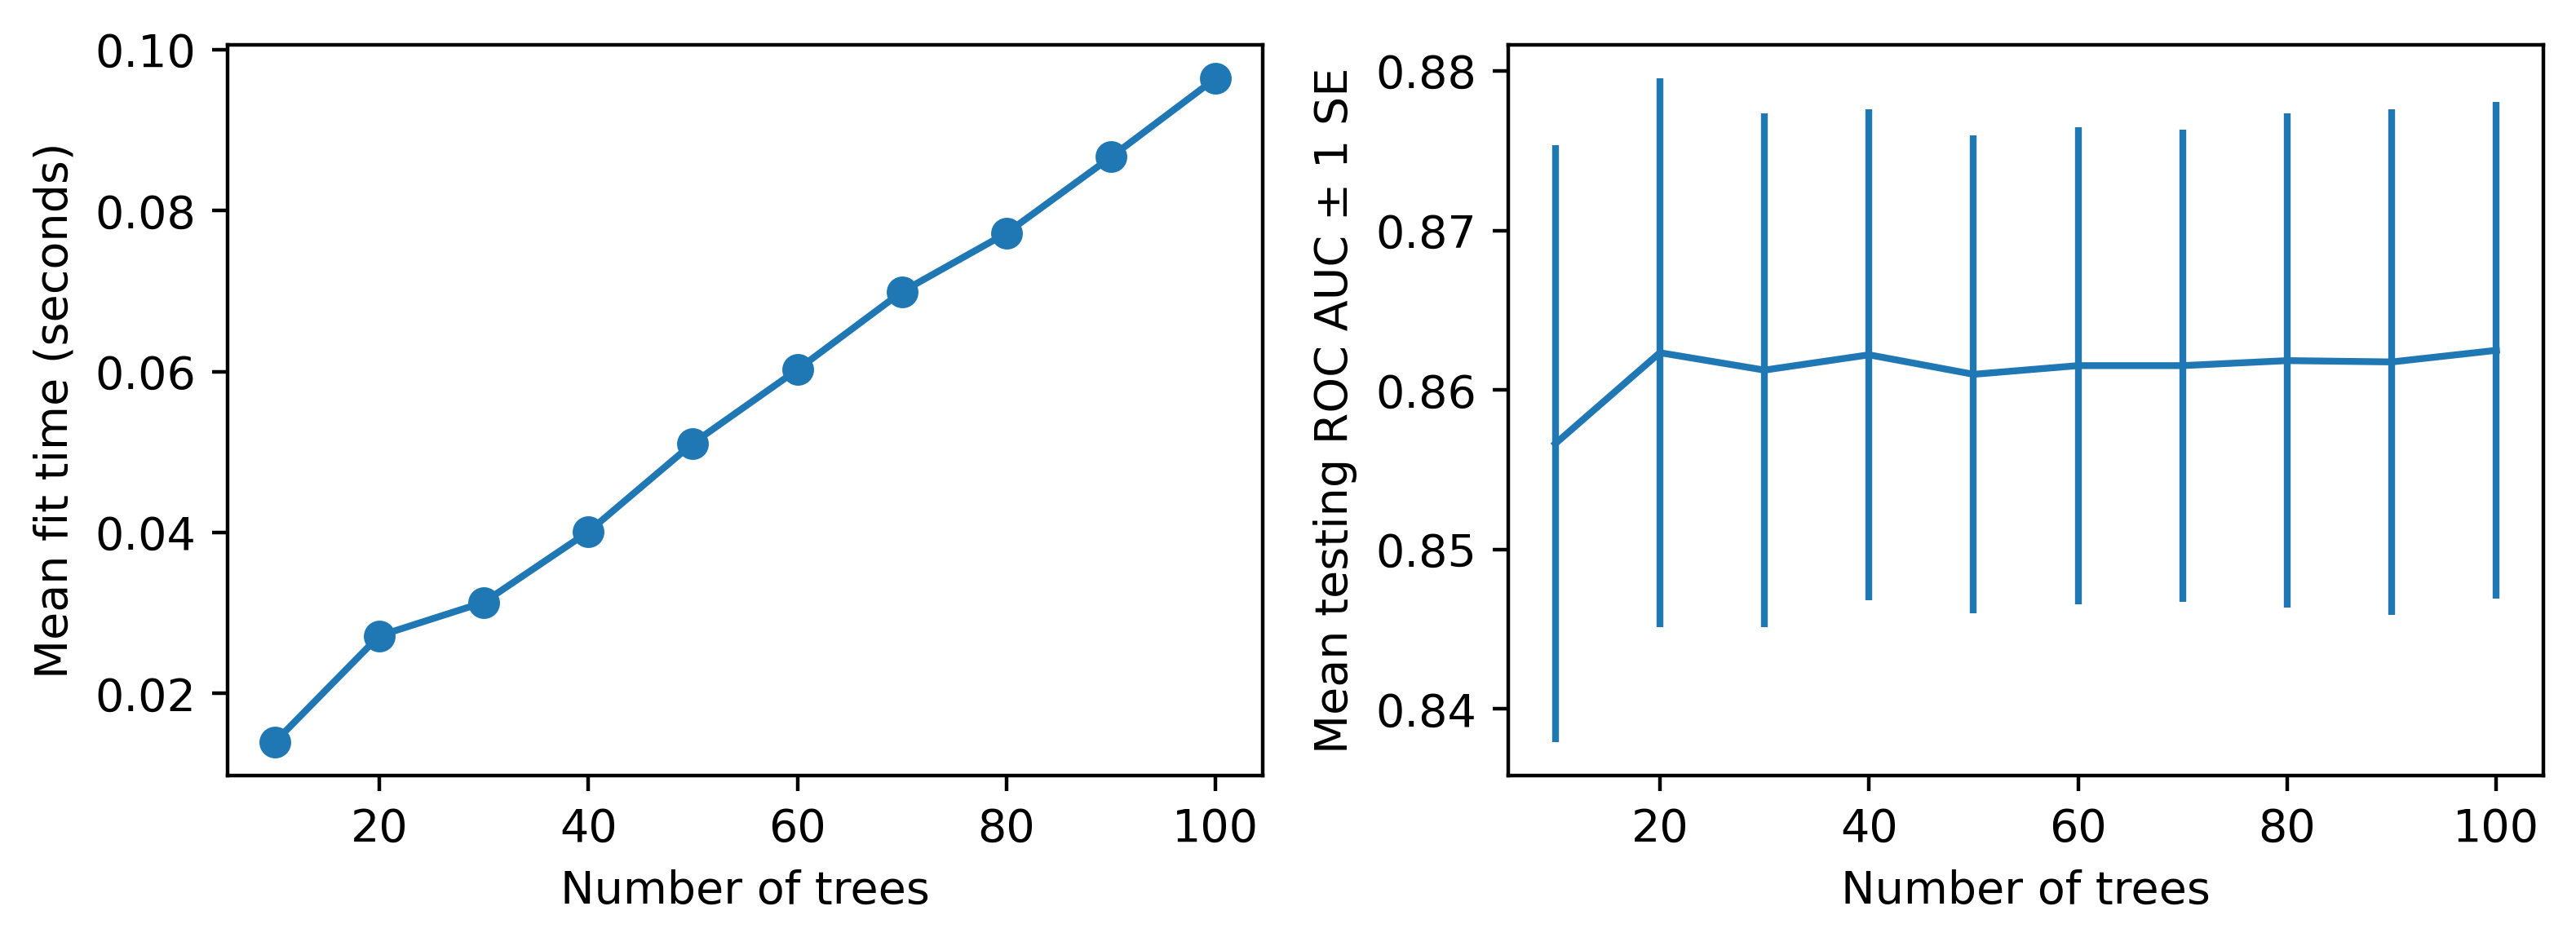

In [23]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

# Thời gian huấn luyện
axs[0].plot(
    cv_rf_ex_results_df['param_n_estimators'],
    cv_rf_ex_results_df['mean_fit_time'], '-o'
)
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')

# ROC AUC theo số cây
axs[1].errorbar(
    cv_rf_ex_results_df['param_n_estimators'],
    cv_rf_ex_results_df['mean_test_score'],
    yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4)
)
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC ± 1 SE')

plt.tight_layout()
plt.show()


# Kết thúc